# Z-Score Returns — Backtest

Ce notebook :
1. Construit un dictionnaire de DataFrames (un par crypto) avec les **rendements journaliers non-logarithmiques**
2. Calcule plusieurs **z-scores** des rendements sur différentes fenêtres (rolling **et** EWM)
3. Construit un **z-score composite** (moyenne des z-scores)
4. Backteste la stratégie Long/Short sur ce signal
5. Évalue les performances : Sharpe, drawdown, PnL cumulé

**Paramètre `METHOD`** : `'rolling'` ou `'ewm'` — toggle global en section 0.

In [1]:
import pathlib, sys
ROOT = pathlib.Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── Paramètres globaux ────────────────────────────────────────────────────────
RAW      = ROOT / 'data' / 'raw'
EXCHANGE = 'binance-futures'
ASSETS   = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'LTCUSDT', 'BNBUSDT']
WINDOWS  = [15, 30, 60, 80, 100, 150, 200, 250, 300]   # fenêtres z-score
METHOD   = 'rolling'                                     # 'rolling' ou 'ewm'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print(f'ROOT: {ROOT}  |  METHOD: {METHOD}  |  ASSETS: {ASSETS}')

ROOT: /Users/ayman/Downloads/dfi-quant  |  METHOD: rolling  |  ASSETS: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'LTCUSDT', 'BNBUSDT']


## 1. Chargement des données & rendements journaliers

In [2]:
def load_ohlcv(symbol: str) -> pd.DataFrame:
    base = RAW / f'exchange={EXCHANGE}' / 'data_type=ohlcv_1d' / f'symbol={symbol}'
    parts = sorted(base.rglob('part-*.parquet'))
    if not parts:
        return pd.DataFrame()
    df = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
    df['date'] = pd.to_datetime(df['ts_open'], unit='us', utc=True).dt.normalize()
    df = df.sort_values('date').drop_duplicates('date').set_index('date')
    return df

# ── Dictionnaire {symbol: DataFrame avec ret_1d} ─────────────────────────────
returns: dict[str, pd.DataFrame] = {}

for sym in ASSETS:
    raw = load_ohlcv(sym)
    if raw.empty:
        print(f'  {sym}: aucune donnée')
        continue
    df = pd.DataFrame(index=raw.index)
    df['close']   = raw['close'].astype(float)
    df['ret_1d']  = df['close'] / df['close'].shift(1) - 1   # rendement simple (non-log)
    returns[sym]  = df
    print(f'  {sym}: {len(df)} jours  {df.index[0].date()} → {df.index[-1].date()}')

print(f'\n{len(returns)} assets chargés.')

  BTCUSDT: 2322 jours  2020-01-01 → 2026-05-10


  ETHUSDT: 2322 jours  2020-01-01 → 2026-05-10


  SOLUSDT: 2065 jours  2020-09-14 → 2026-05-10


  LTCUSDT: 2314 jours  2020-01-09 → 2026-05-10


  BNBUSDT: 2282 jours  2020-02-10 → 2026-05-10

5 assets chargés.


### Aperçu du DataFrame de rendements (5 dernières lignes par asset)

In [3]:
from IPython.display import display

for sym, df in returns.items():
    display_df = df[['close', 'ret_1d']].tail(10).copy()
    display_df.columns = ['close ($)', 'ret_1d (%)']
    display_df['ret_1d (%)'] = (display_df['ret_1d (%)'] * 100).round(3)
    display_df.index = display_df.index.strftime('%Y-%m-%d')

    print(f'\n{sym}')
    display(display_df.style.format({'close ($)': '{:,.2f}', 'ret_1d (%)': '{:+.3f}%'}))



BTCUSDT


,close ($),ret_1d (%)
date,,
2026-05-01,"78,192.00",+2.472%
2026-05-02,"78,652.90",+0.589%
2026-05-03,"78,529.00",-0.158%
2026-05-04,"79,826.10",+1.652%
2026-05-05,"80,861.90",+1.298%
2026-05-06,"81,390.10",+0.653%
2026-05-07,"79,969.40",-1.746%
2026-05-08,"80,155.20",+0.232%
2026-05-09,"80,634.00",+0.597%



ETHUSDT


,close ($),ret_1d (%)
date,,
2026-05-01,"2,294.34",+1.677%
2026-05-02,"2,315.90",+0.940%
2026-05-03,"2,321.67",+0.249%
2026-05-04,"2,346.11",+1.053%
2026-05-05,"2,359.47",+0.569%
2026-05-06,"2,349.70",-0.414%
2026-05-07,"2,289.91",-2.545%
2026-05-08,"2,306.17",+0.710%
2026-05-09,"2,325.22",+0.826%



SOLUSDT


,close ($),ret_1d (%)
date,,
2026-05-01,83.70,+0.795%
2026-05-02,84.23,+0.633%
2026-05-03,83.87,-0.427%
2026-05-04,84.05,+0.215%
2026-05-05,86.24,+2.606%
2026-05-06,89.10,+3.316%
2026-05-07,88.40,-0.786%
2026-05-08,91.97,+4.038%
2026-05-09,93.07,+1.196%



LTCUSDT


,close ($),ret_1d (%)
date,,
2026-05-01,55.36,+0.381%
2026-05-02,55.33,-0.054%
2026-05-03,55.27,-0.108%
2026-05-04,54.92,-0.633%
2026-05-05,56.30,+2.513%
2026-05-06,56.72,+0.746%
2026-05-07,56.41,-0.547%
2026-05-08,58.28,+3.315%
2026-05-09,57.97,-0.532%



BNBUSDT


,close ($),ret_1d (%)
date,,
2026-05-01,615.72,+0.018%
2026-05-02,618.33,+0.424%
2026-05-03,617.58,-0.121%
2026-05-04,623.03,+0.882%
2026-05-05,630.75,+1.239%
2026-05-06,648.12,+2.754%
2026-05-07,637.31,-1.668%
2026-05-08,649.78,+1.957%
2026-05-09,650.08,+0.046%


## 2. Calcul des z-scores

In [4]:
def zscore_rolling(series: pd.Series, window: int) -> pd.Series:
    """Z-score avec moyenne et écart-type rolling (causal, NaN pendant warmup)."""
    mu    = series.rolling(window, min_periods=window).mean()
    sigma = series.rolling(window, min_periods=window).std()
    return (series - mu) / sigma.replace(0, np.nan)

def zscore_ewm(series: pd.Series, span: int) -> pd.Series:
    """Z-score avec moyenne et écart-type EWM (causal, NaN pendant warmup)."""
    mu    = series.ewm(span=span, min_periods=span).mean()
    sigma = series.ewm(span=span, min_periods=span).std()
    return (series - mu) / sigma.replace(0, np.nan)

ZSCORE_FN = zscore_rolling if METHOD == 'rolling' else zscore_ewm
print(f'Méthode z-score : {METHOD}')

Méthode z-score : rolling


In [5]:
# ── Calcul des z-scores par asset ─────────────────────────────────────────────
for sym, df in returns.items():
    for w in WINDOWS:
        col = f'z_{w}d'
        df[col] = ZSCORE_FN(df['ret_1d'], w)

    # Z-score composite = moyenne des z-scores (skipna=False : NaN tant que toutes les fenêtres ne sont pas prêtes)
    z_cols = [f'z_{w}d' for w in WINDOWS]
    df['z_composite'] = df[z_cols].mean(axis=1, skipna=False)

    returns[sym] = df

print('Z-scores calculés. Colonnes disponibles :')
print(list(returns[ASSETS[0]].columns))

Z-scores calculés. Colonnes disponibles :
['close', 'ret_1d', 'z_15d', 'z_30d', 'z_60d', 'z_80d', 'z_100d', 'z_150d', 'z_200d', 'z_250d', 'z_300d', 'z_composite']


### Aperçu des z-scores (10 dernières lignes)

In [6]:
from IPython.display import display

z_display_cols = [f'z_{w}d' for w in WINDOWS] + ['z_composite']

for sym, df in returns.items():
    display_df = df[z_display_cols].tail(10).round(3).copy()
    display_df.index = display_df.index.strftime('%Y-%m-%d')
    print(f'\n── {sym}  (méthode: {METHOD}) ─────────────────────────────────────────')
    display(display_df)


── BTCUSDT  (méthode: rolling) ─────────────────────────────────────────


,z_15d,z_30d,z_60d,z_80d,z_100d,z_150d,z_200d,z_250d,z_300d,z_composite
date,,,,,,,,,,
2026-05-01,1.245,1.019,1.001,0.988,0.849,0.966,1.031,1.063,1.101,1.029
2026-05-02,0.266,0.015,0.148,0.159,0.223,0.255,0.289,0.285,0.290,0.215
2026-05-03,-0.268,-0.371,-0.148,-0.173,-0.024,-0.033,-0.007,-0.019,-0.034,-0.120
2026-05-04,0.799,0.553,0.695,0.639,0.568,0.647,0.696,0.722,0.745,0.674
2026-05-05,0.673,0.397,0.497,0.483,0.439,0.508,0.551,0.576,0.594,0.524
2026-05-06,0.167,0.040,0.159,0.186,0.230,0.263,0.298,0.305,0.323,0.219
2026-05-07,-1.508,-1.190,-1.055,-0.866,-0.559,-0.648,-0.638,-0.682,-0.713,-0.873
2026-05-08,0.049,-0.106,-0.026,-0.003,0.098,0.113,0.142,0.133,0.144,0.060
2026-05-09,0.259,0.110,0.178,0.148,0.203,0.249,0.280,0.284,0.304,0.224



── ETHUSDT  (méthode: rolling) ─────────────────────────────────────────


,z_15d,z_30d,z_60d,z_80d,z_100d,z_150d,z_200d,z_250d,z_300d,z_composite
date,,,,,,,,,,
2026-05-01,0.858,0.506,0.474,0.455,0.473,0.499,0.544,0.536,0.448,0.533
2026-05-02,0.621,0.190,0.213,0.210,0.281,0.307,0.330,0.321,0.248,0.302
2026-05-03,0.172,-0.073,0.022,-0.006,0.105,0.109,0.130,0.131,0.058,0.072
2026-05-04,0.523,0.221,0.285,0.265,0.306,0.328,0.353,0.357,0.279,0.324
2026-05-05,0.298,0.061,0.086,0.117,0.171,0.191,0.213,0.219,0.153,0.168
2026-05-06,-0.343,-0.306,-0.271,-0.223,-0.069,-0.085,-0.064,-0.065,-0.111,-0.171
2026-05-07,-1.572,-1.077,-1.034,-0.897,-0.603,-0.679,-0.663,-0.670,-0.697,-0.877
2026-05-08,0.540,0.210,0.156,0.156,0.232,0.255,0.262,0.259,0.200,0.252
2026-05-09,0.550,0.246,0.207,0.183,0.247,0.287,0.290,0.289,0.232,0.281



── SOLUSDT  (méthode: rolling) ─────────────────────────────────────────


,z_15d,z_30d,z_60d,z_80d,z_100d,z_150d,z_200d,z_250d,z_300d,z_composite
date,,,,,,,,,,
2026-05-01,0.780,0.245,0.291,0.228,0.295,0.304,0.325,0.278,0.232,0.331
2026-05-02,0.622,0.145,0.232,0.160,0.250,0.266,0.276,0.229,0.193,0.264
2026-05-03,-0.189,-0.231,-0.121,-0.177,-0.022,-0.044,-0.021,-0.042,-0.080,-0.103
2026-05-04,0.142,0.019,0.099,0.056,0.141,0.133,0.150,0.129,0.086,0.106
2026-05-05,2.153,0.907,0.951,0.851,0.737,0.813,0.805,0.762,0.701,0.965
2026-05-06,2.148,1.098,1.176,1.058,0.927,1.008,1.001,0.942,0.885,1.138
2026-05-07,-0.636,-0.391,-0.356,-0.282,-0.129,-0.164,-0.131,-0.139,-0.169,-0.266
2026-05-08,2.077,1.549,1.444,1.265,1.105,1.216,1.194,1.124,1.064,1.338
2026-05-09,0.384,0.339,0.383,0.324,0.355,0.397,0.406,0.374,0.334,0.366



── LTCUSDT  (méthode: rolling) ─────────────────────────────────────────


,z_15d,z_30d,z_60d,z_80d,z_100d,z_150d,z_200d,z_250d,z_300d,z_composite
date,,,,,,,,,,
2026-05-01,0.416,0.170,0.183,0.134,0.192,0.222,0.190,0.177,0.132,0.202
2026-05-02,0.052,-0.171,-0.048,-0.066,0.039,0.073,0.054,0.045,0.009,-0.001
2026-05-03,-0.065,-0.168,-0.045,-0.080,0.020,0.047,0.034,0.034,-0.007,-0.026
2026-05-04,-0.896,-0.494,-0.356,-0.291,-0.160,-0.154,-0.132,-0.118,-0.153,-0.306
2026-05-05,2.481,1.548,1.373,1.095,0.919,1.002,0.830,0.787,0.735,1.197
2026-05-06,0.642,0.356,0.360,0.303,0.319,0.349,0.287,0.274,0.241,0.348
2026-05-07,-0.699,-0.446,-0.389,-0.266,-0.130,-0.118,-0.107,-0.098,-0.124,-0.264
2026-05-08,2.486,2.148,1.784,1.403,1.198,1.303,1.077,1.009,0.962,1.486
2026-05-09,-0.570,-0.527,-0.378,-0.291,-0.155,-0.118,-0.108,-0.099,-0.122,-0.263



── BNBUSDT  (méthode: rolling) ─────────────────────────────────────────


,z_15d,z_30d,z_60d,z_80d,z_100d,z_150d,z_200d,z_250d,z_300d,z_composite
date,,,,,,,,,,
2026-05-01,0.182,-0.013,0.033,0.003,0.125,0.091,0.135,0.038,-0.001,0.066
2026-05-02,0.566,0.138,0.248,0.190,0.273,0.272,0.281,0.169,0.140,0.253
2026-05-03,0.007,-0.186,-0.017,-0.073,0.076,0.042,0.063,-0.010,-0.049,-0.016
2026-05-04,0.838,0.446,0.540,0.423,0.438,0.450,0.449,0.326,0.298,0.468
2026-05-05,1.446,0.675,0.722,0.609,0.556,0.596,0.582,0.448,0.421,0.673
2026-05-06,2.341,1.505,1.555,1.331,1.101,1.211,1.177,0.952,0.945,1.347
2026-05-07,-1.418,-1.118,-1.019,-0.852,-0.498,-0.605,-0.562,-0.536,-0.582,-0.799
2026-05-08,1.433,1.128,1.140,0.934,0.819,0.879,0.862,0.681,0.668,0.949
2026-05-09,-0.080,-0.143,0.007,-0.032,0.110,0.094,0.102,0.036,0.009,0.011


### Distribution des z-scores

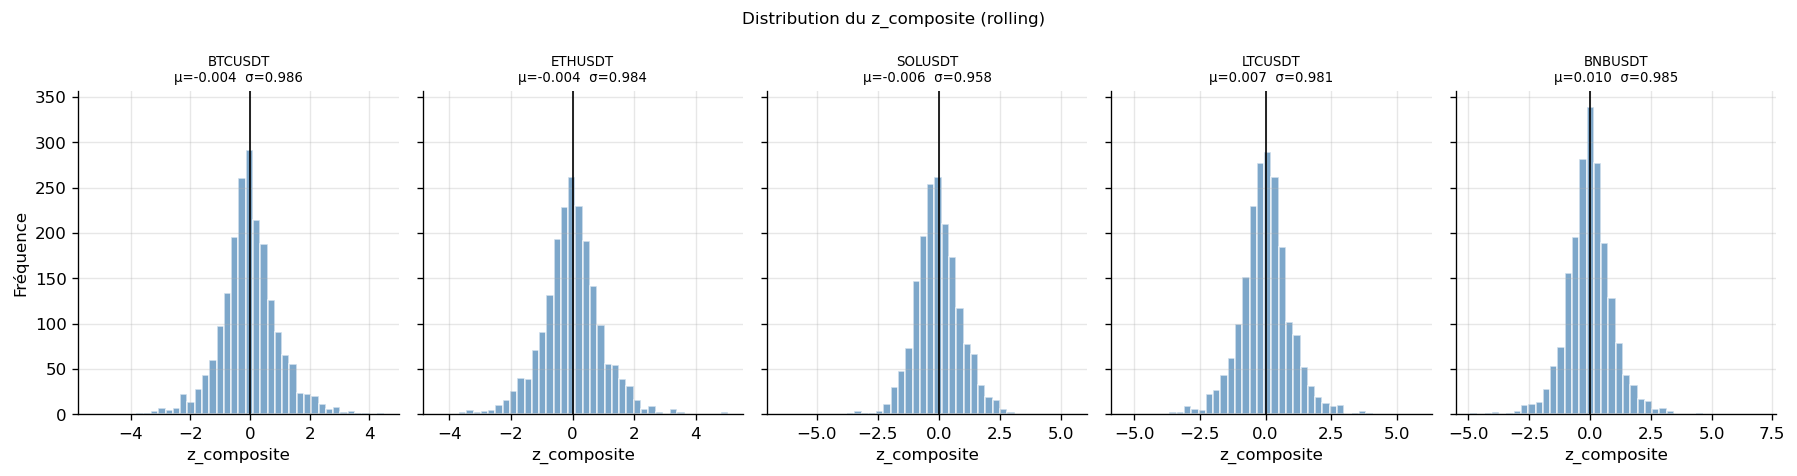

In [7]:
fig, axes = plt.subplots(1, len(returns), figsize=(15, 4), sharey=True)

for ax, (sym, df) in zip(axes, returns.items()):
    z = df['z_composite'].dropna()
    ax.hist(z, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='k', lw=1)
    ax.set_title(f'{sym}\nμ={z.mean():.3f}  σ={z.std():.3f}', fontsize=8)
    ax.set_xlabel('z_composite')

axes[0].set_ylabel('Fréquence')
fig.suptitle(f'Distribution du z_composite ({METHOD})', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Backtest — signal Long/Short

**Logique :**
- `signal[t] = +1` si `z_composite[t] > 0`  (position longue)
- `signal[t] = -1` si `z_composite[t] <= 0` (position courte)
- On entre à la clôture du jour `t` et on capture le rendement du jour `t+1` : `ret_fwd[t] = ret_1d.shift(-1)[t]`
- `strategy_ret[t] = signal[t] × ret_fwd[t]`

In [8]:
for sym, df in returns.items():
    df['signal']       = np.where(df['z_composite'] > 0, -1.0, 1.0)
    df['ret_fwd']      = df['ret_1d'].shift(-1)              # rendement du lendemain
    df['strat_ret']    = df['signal'] * df['ret_fwd']        # P&L journalier de la stratégie
    df['portf_value']  = (1 + df['strat_ret'].fillna(0)).cumprod()  # valeur normalisée du portefeuille
    df['bh_value']     = (1 + df['ret_1d'].fillna(0)).cumprod()     # buy & hold pour comparaison
    returns[sym] = df

print('Signaux et rendements de stratégie calculés.')
print('Aperçu BTCUSDT :')
cols = ['z_composite', 'signal', 'ret_fwd', 'strat_ret', 'portf_value']
preview = returns['BTCUSDT'][cols].dropna().tail(10).copy()
preview.index = preview.index.strftime('%Y-%m-%d')
for col in ['z_composite', 'ret_fwd', 'strat_ret']:
    preview[col] = preview[col].round(5)
preview['portf_value'] = preview['portf_value'].round(4)
print(preview.to_string())

Signaux et rendements de stratégie calculés.
Aperçu BTCUSDT :
            z_composite  signal  ret_fwd  strat_ret  portf_value
date                                                            
2026-04-30      0.29241    -1.0  0.02472   -0.02472       1.6793
2026-05-01      1.02936    -1.0  0.00589   -0.00589       1.6694
2026-05-02      0.21454    -1.0 -0.00158    0.00158       1.6720
2026-05-03     -0.11967     1.0  0.01652    0.01652       1.6996
2026-05-04      0.67377    -1.0  0.01298   -0.01298       1.6776
2026-05-05      0.52413    -1.0  0.00653   -0.00653       1.6666
2026-05-06      0.21897    -1.0 -0.01746    0.01746       1.6957
2026-05-07     -0.87323     1.0  0.00232    0.00232       1.6997
2026-05-08      0.06035    -1.0  0.00597   -0.00597       1.6895
2026-05-09      0.22405    -1.0  0.01914   -0.01914       1.6572


## 4. Évaluation des performances

In [9]:
def sharpe(rets: pd.Series, freq: int = 252) -> float:
    r = rets.dropna()
    if r.std() == 0:
        return float('nan')
    return (r.mean() / r.std()) * np.sqrt(freq)

def max_drawdown(cum_rets: pd.Series) -> float:
    rolling_max = cum_rets.cummax()
    dd = (cum_rets - rolling_max) / rolling_max
    return dd.min()

def win_rate(rets: pd.Series) -> float:
    r = rets.dropna()
    return (r > 0).sum() / len(r)

rows = []
for sym, df in returns.items():
    sr   = df['strat_ret'].dropna()
    bh   = df['ret_1d'].dropna()
    rows.append({
        'Asset':            sym,
        'Sharpe strat':     round(sharpe(sr), 3),
        'Sharpe B&H':       round(sharpe(bh), 3),
        'Return total (%)': round((df['portf_value'].iloc[-1] - 1) * 100, 1),
        'Max Drawdown (%)': round(max_drawdown(df['portf_value']) * 100, 1),
        'Win rate (%)':     round(win_rate(sr) * 100, 1),
        'N jours':          len(sr),
    })

summary = pd.DataFrame(rows).set_index('Asset')
print(f'Résultats backtest — méthode z-score : {METHOD}\n')
print(summary.to_string())

Résultats backtest — méthode z-score : rolling

         Sharpe strat  Sharpe B&H  Return total (%)  Max Drawdown (%)  Win rate (%)  N jours
Asset                                                                                       
BTCUSDT         0.370       0.779              65.7             -76.3          52.9     2321
ETHUSDT         0.542       0.808             239.0             -80.2          52.8     2321
SOLUSDT         0.455       0.909             -24.4             -96.7          51.0     2064
LTCUSDT         0.361       0.419              -6.7             -78.7          52.2     2313
BNBUSDT         0.328       0.859             -39.3             -86.4          54.0     2281


## 5. Visualisations

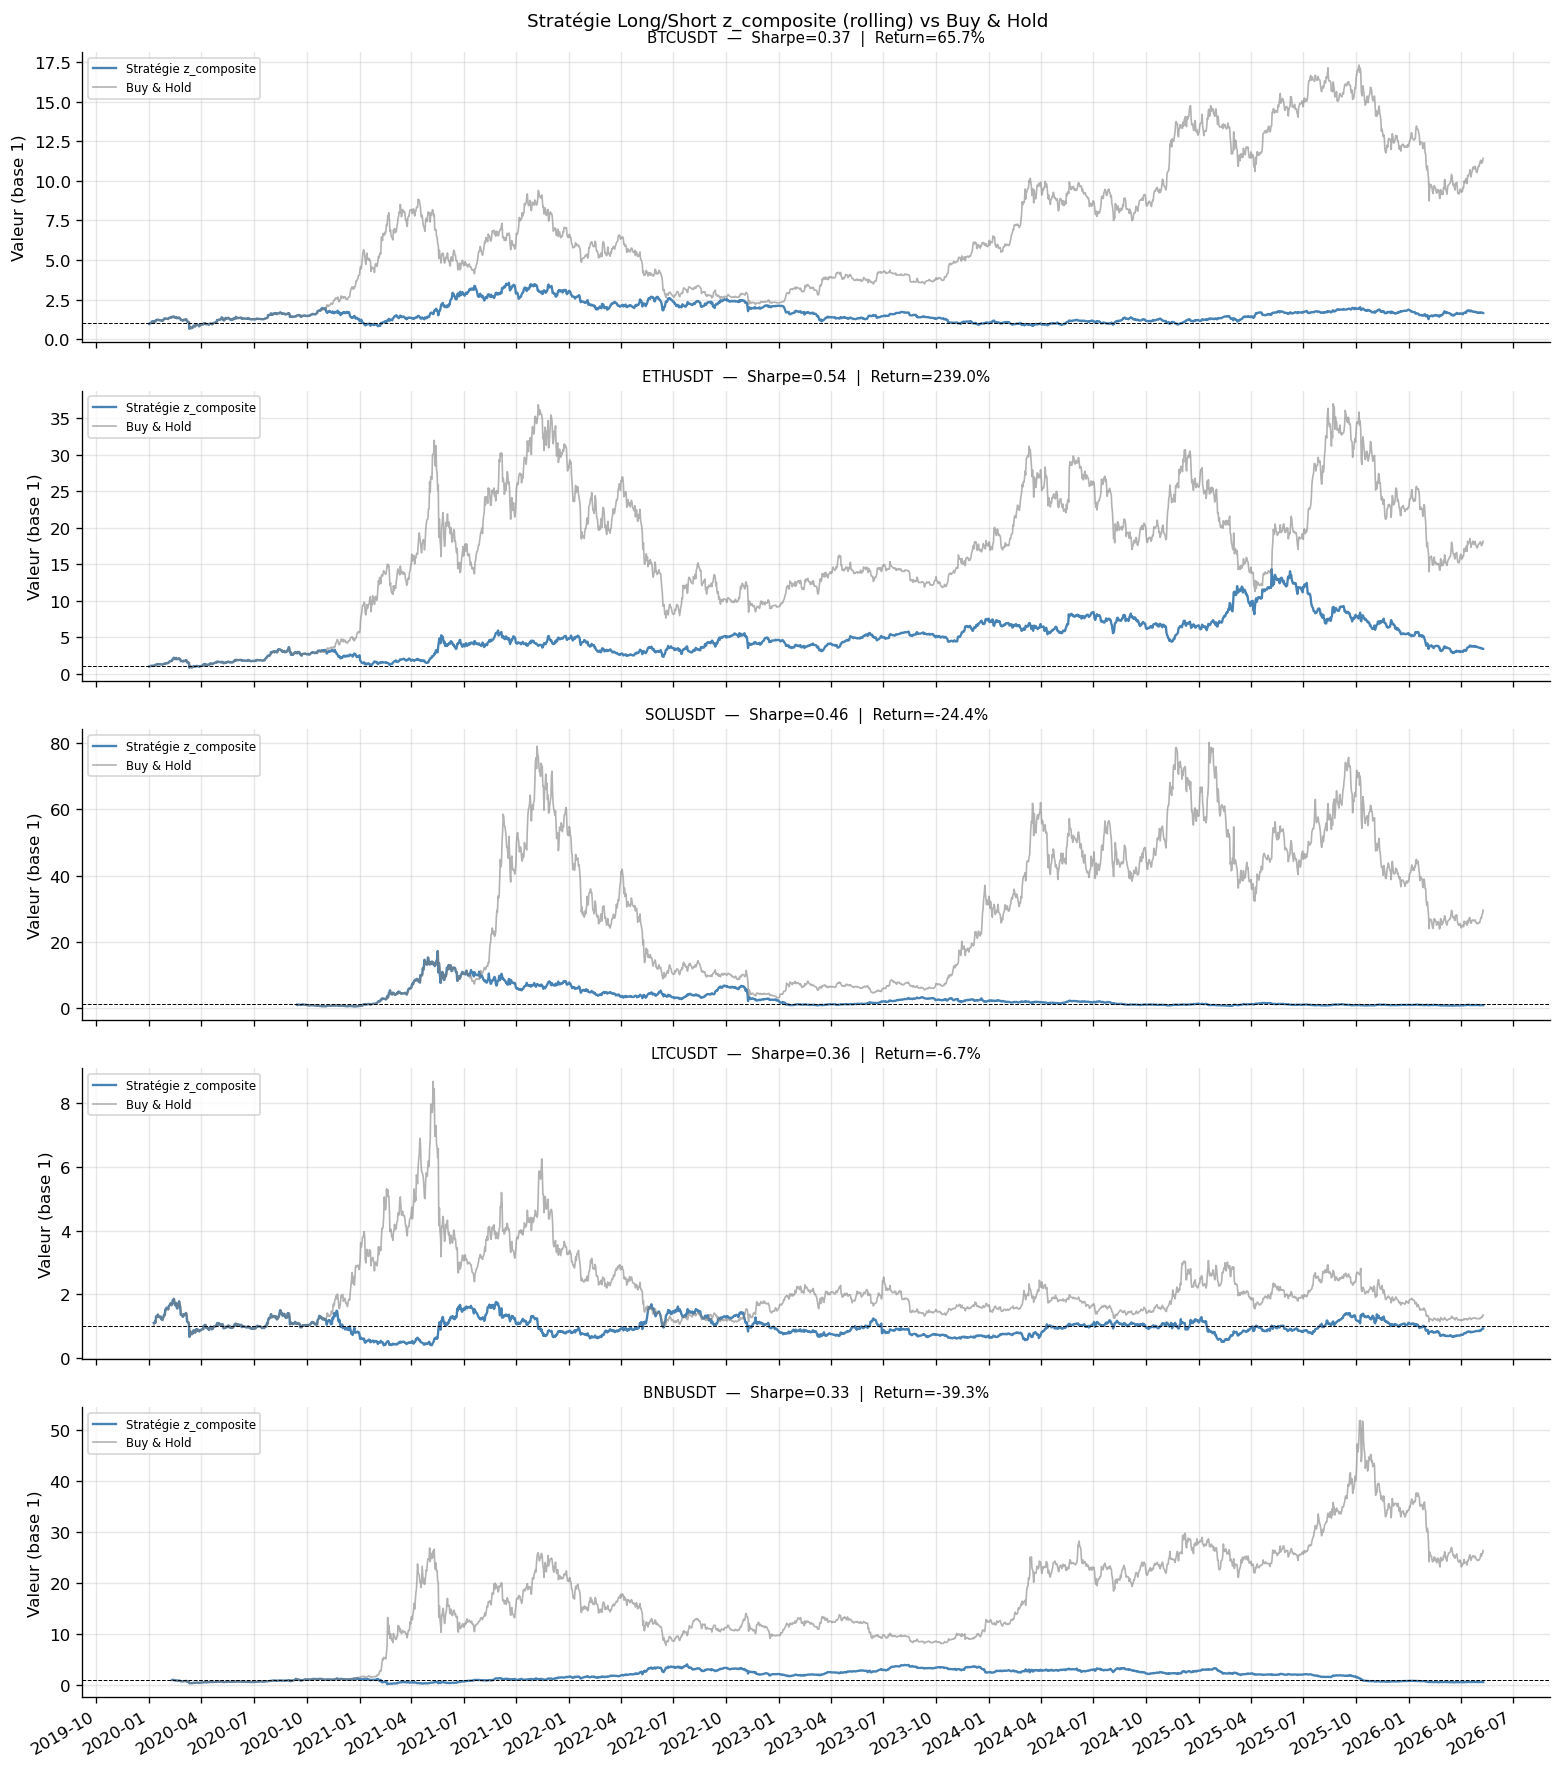

In [10]:
# ── Courbes de valeur cumulée : stratégie vs Buy & Hold ───────────────────────
fig, axes = plt.subplots(len(returns), 1, figsize=(13, 3 * len(returns)), sharex=True)

for ax, (sym, df) in zip(axes, returns.items()):
    valid = df[['portf_value', 'bh_value']].dropna()
    ax.plot(valid.index, valid['portf_value'], lw=1.4, color='steelblue', label='Stratégie z_composite')
    ax.plot(valid.index, valid['bh_value'],    lw=1.0, color='gray',      alpha=0.6, label='Buy & Hold')
    ax.axhline(1, color='k', lw=0.6, ls='--')
    sh = sharpe(df['strat_ret'].dropna())
    final = df['portf_value'].iloc[-1]
    ax.set_title(f'{sym}  —  Sharpe={sh:.2f}  |  Return={((final-1)*100):.1f}%', fontsize=9)
    ax.set_ylabel('Valeur (base 1)')
    ax.legend(fontsize=7, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

fig.suptitle(f'Stratégie Long/Short z_composite ({METHOD}) vs Buy & Hold', fontsize=11)
plt.gcf().autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

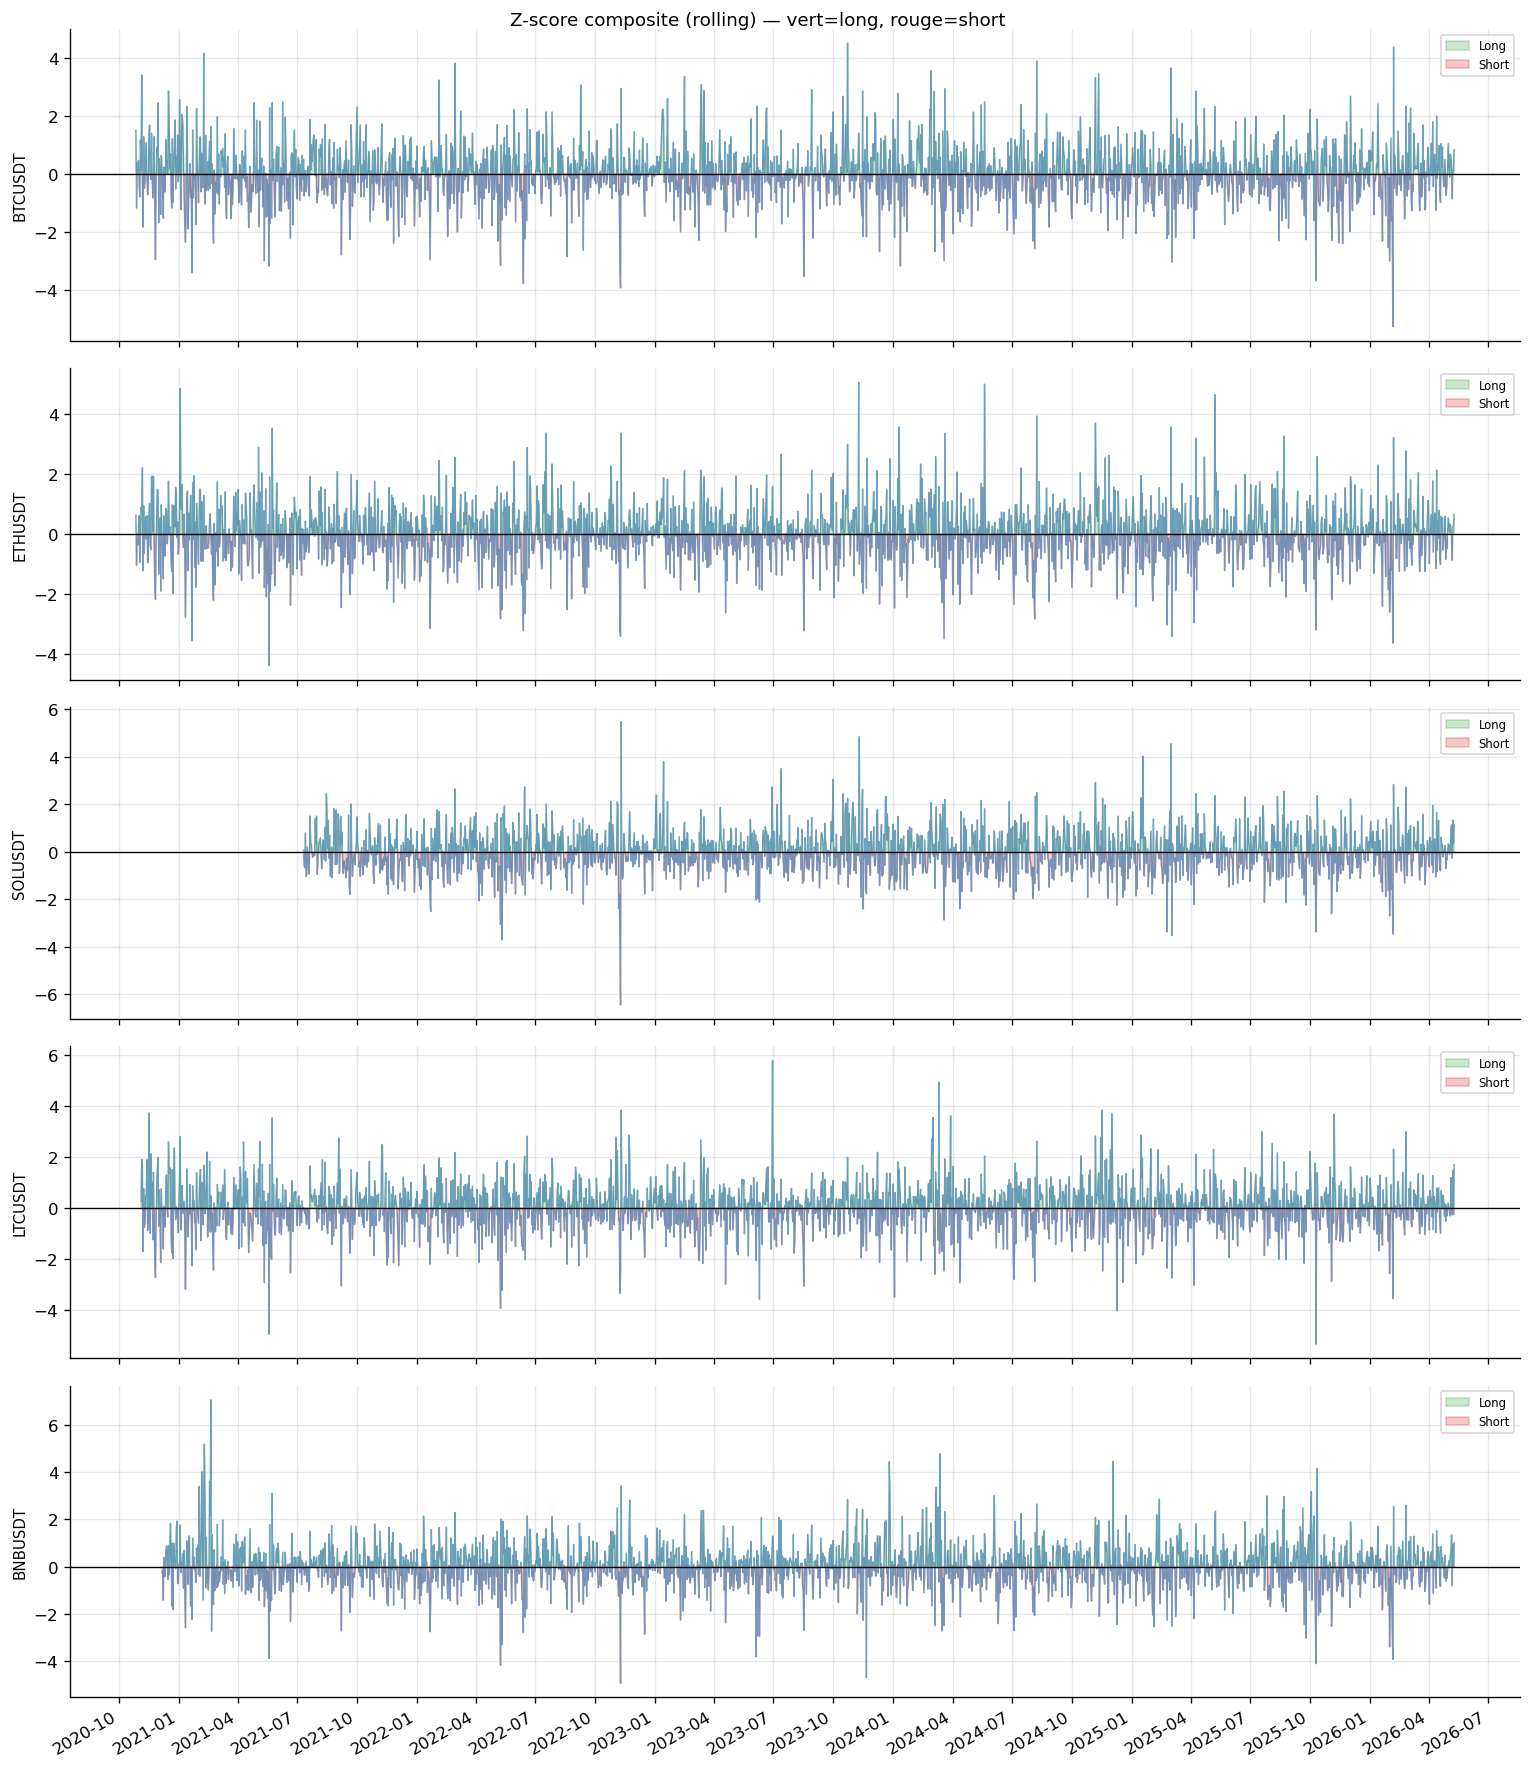

In [11]:
# ── Z-score composite dans le temps + signal ──────────────────────────────────
fig, axes = plt.subplots(len(returns), 1, figsize=(13, 3 * len(returns)), sharex=True)

for ax, (sym, df) in zip(axes, returns.items()):
    z = df['z_composite'].dropna()
    ax.plot(z.index, z.values, lw=0.8, color='steelblue', alpha=0.7)
    ax.fill_between(z.index, 0, z.values,
                    where=z.values > 0, color='tab:green', alpha=0.25, label='Long')
    ax.fill_between(z.index, 0, z.values,
                    where=z.values <= 0, color='tab:red', alpha=0.25, label='Short')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_ylabel(sym, fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

fig.suptitle(f'Z-score composite ({METHOD}) — vert=long, rouge=short', fontsize=11)
plt.gcf().autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

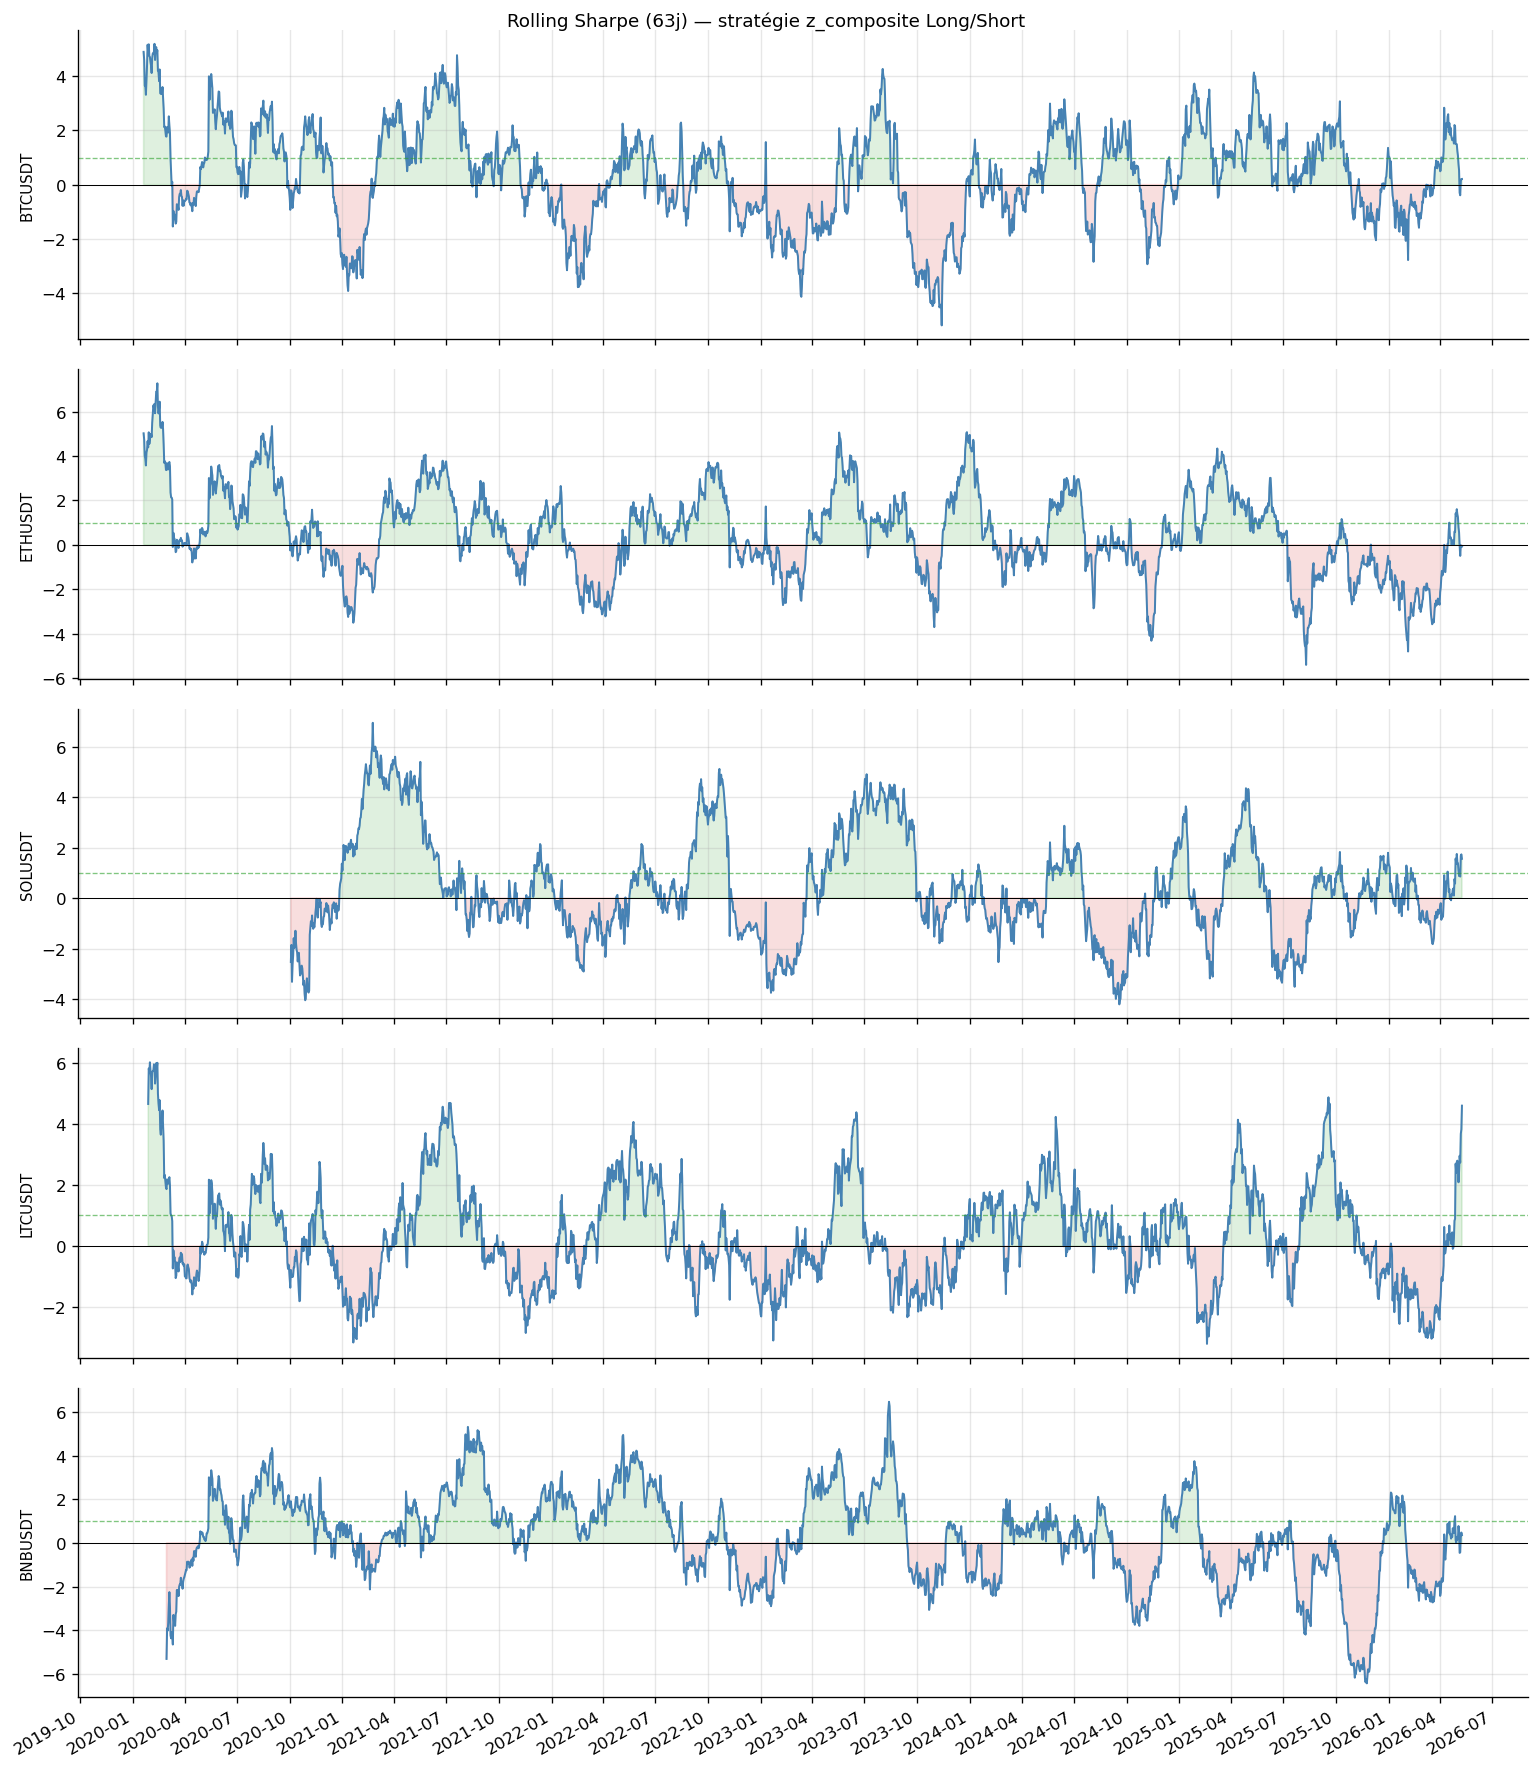

In [12]:
# ── Rolling Sharpe (63j) par asset ────────────────────────────────────────────
fig, axes = plt.subplots(len(returns), 1, figsize=(13, 3 * len(returns)), sharex=True)

for ax, (sym, df) in zip(axes, returns.items()):
    sr = df['strat_ret'].dropna()
    roll_sharpe = sr.rolling(63, min_periods=20).apply(
        lambda x: (x.mean() / x.std()) * np.sqrt(252) if x.std() > 0 else np.nan
    )
    ax.plot(roll_sharpe.index, roll_sharpe.values, lw=1.2, color='steelblue')
    ax.axhline(0, color='k', lw=0.6)
    ax.axhline(1, color='tab:green', lw=0.8, ls='--', alpha=0.6)
    ax.fill_between(roll_sharpe.index, 0, roll_sharpe.values,
                    where=roll_sharpe.values >= 0, color='tab:green', alpha=0.15)
    ax.fill_between(roll_sharpe.index, 0, roll_sharpe.values,
                    where=roll_sharpe.values < 0,  color='tab:red',   alpha=0.15)
    ax.set_ylabel(sym, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

fig.suptitle('Rolling Sharpe (63j) — stratégie z_composite Long/Short', fontsize=11)
plt.gcf().autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

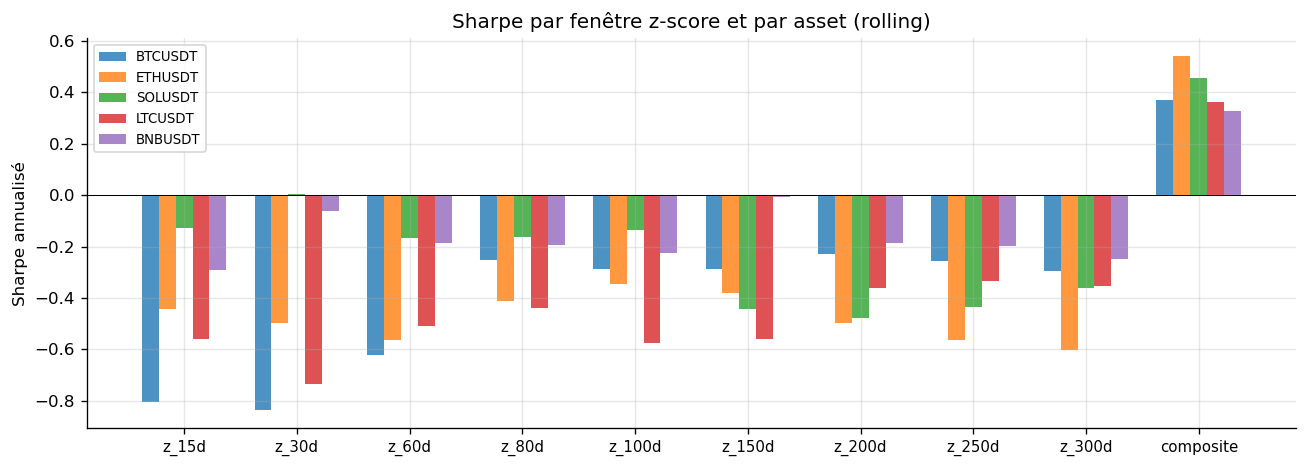


Tableau Sharpe par fenêtre :
           BTCUSDT  ETHUSDT  SOLUSDT  LTCUSDT  BNBUSDT
z_15d       -0.804   -0.442   -0.126   -0.561   -0.291
z_30d       -0.837   -0.496    0.003   -0.735   -0.061
z_60d       -0.621   -0.561   -0.169   -0.508   -0.186
z_80d       -0.252   -0.411   -0.165   -0.440   -0.195
z_100d      -0.287   -0.347   -0.135   -0.575   -0.225
z_150d      -0.285   -0.380   -0.441   -0.561   -0.006
z_200d      -0.228   -0.498   -0.478   -0.360   -0.187
z_250d      -0.254   -0.564   -0.436   -0.332   -0.198
z_300d      -0.297   -0.603   -0.361   -0.354   -0.250
composite    0.370    0.542    0.455    0.361    0.328


In [13]:
# ── Comparaison des Sharpe par fenêtre de z-score (par asset) ─────────────────
sharpe_matrix = {}
for sym, df in returns.items():
    sharpes = []
    for w in WINDOWS:
        sig   = np.where(df[f'z_{w}d'] > 0, 1.0, -1.0)
        sr    = pd.Series(sig, index=df.index) * df['ret_fwd']
        sharpes.append(sharpe(sr.dropna()))
    # composite
    sharpes.append(sharpe(df['strat_ret'].dropna()))
    sharpe_matrix[sym] = sharpes

labels = [f'z_{w}d' for w in WINDOWS] + ['composite']
df_sharpe = pd.DataFrame(sharpe_matrix, index=labels)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(labels))
width = 0.15
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
for i, (sym, col) in enumerate(zip(ASSETS, colors)):
    ax.bar(x + i * width, df_sharpe[sym].values, width, label=sym, color=col, alpha=0.8)

ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(x + width * (len(ASSETS) - 1) / 2)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Sharpe annualisé')
ax.set_title(f'Sharpe par fenêtre z-score et par asset ({METHOD})')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('\nTableau Sharpe par fenêtre :')
print(df_sharpe.round(3).to_string())

## 6. Comparaison rolling vs EWM

  rolling   Sharpe=-0.549  Return final=-97.8%
  ewm       Sharpe=-0.584  Return final=-98.2%


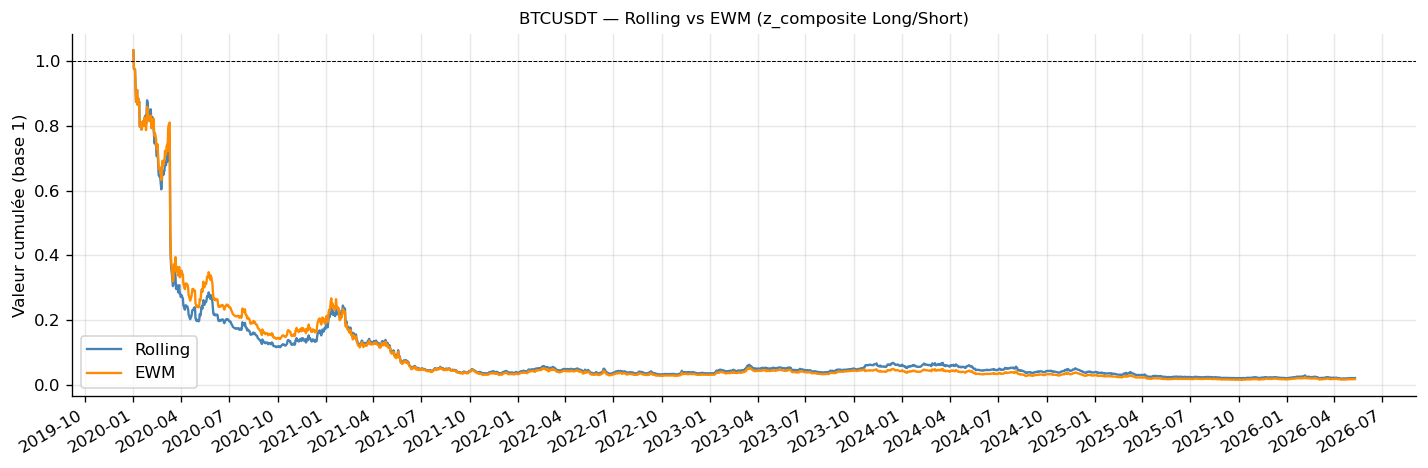

In [14]:
ASSET_COMPARE = 'BTCUSDT'
df_cmp = returns[ASSET_COMPARE][['ret_1d', 'ret_fwd']].copy()

for w in WINDOWS:
    df_cmp[f'z_roll_{w}d'] = zscore_rolling(df_cmp['ret_1d'], w)
    df_cmp[f'z_ewm_{w}d']  = zscore_ewm(df_cmp['ret_1d'], w)

z_roll_cols = [f'z_roll_{w}d' for w in WINDOWS]
z_ewm_cols  = [f'z_ewm_{w}d'  for w in WINDOWS]
df_cmp['z_roll_comp'] = df_cmp[z_roll_cols].mean(axis=1)
df_cmp['z_ewm_comp']  = df_cmp[z_ewm_cols].mean(axis=1)

for method_name, z_col in [('rolling', 'z_roll_comp'), ('ewm', 'z_ewm_comp')]:
    sig  = np.where(df_cmp[z_col] > 0, 1.0, -1.0)
    sr   = pd.Series(sig, index=df_cmp.index) * df_cmp['ret_fwd']
    cum  = (1 + sr.fillna(0)).cumprod()
    sh   = sharpe(sr.dropna())
    df_cmp[f'portf_{method_name}'] = cum
    print(f'  {method_name:8s}  Sharpe={sh:.3f}  Return final={(cum.iloc[-1]-1)*100:.1f}%')

fig, ax = plt.subplots(figsize=(12, 4))
valid = df_cmp[['portf_rolling', 'portf_ewm']].dropna()
ax.plot(valid.index, valid['portf_rolling'], lw=1.4, label='Rolling', color='steelblue')
ax.plot(valid.index, valid['portf_ewm'],     lw=1.4, label='EWM',     color='darkorange')
ax.axhline(1, color='k', lw=0.6, ls='--')
ax.set_title(f'{ASSET_COMPARE} — Rolling vs EWM (z_composite Long/Short)', fontsize=10)
ax.set_ylabel('Valeur cumulée (base 1)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.gcf().autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## 7. Résumé final

In [15]:
print('=' * 65)
print(f'  BACKTEST RÉSUMÉ  —  z_composite Long/Short  —  méthode: {METHOD}')
print('=' * 65)
print(summary.to_string())
print('=' * 65)
print(f'  Fenêtres : {WINDOWS}')
print(f'  Signal   : +1 si z_composite > 0, -1 sinon')
print(f'  Entrée   : clôture du jour t  |  Capture return j+1')
print(f'  Sharpe   : annualisé (√252)')
print('=' * 65)

  BACKTEST RÉSUMÉ  —  z_composite Long/Short  —  méthode: rolling
         Sharpe strat  Sharpe B&H  Return total (%)  Max Drawdown (%)  Win rate (%)  N jours
Asset                                                                                       
BTCUSDT         0.370       0.779              65.7             -76.3          52.9     2321
ETHUSDT         0.542       0.808             239.0             -80.2          52.8     2321
SOLUSDT         0.455       0.909             -24.4             -96.7          51.0     2064
LTCUSDT         0.361       0.419              -6.7             -78.7          52.2     2313
BNBUSDT         0.328       0.859             -39.3             -86.4          54.0     2281
  Fenêtres : [15, 30, 60, 80, 100, 150, 200, 250, 300]
  Signal   : +1 si z_composite > 0, -1 sinon
  Entrée   : clôture du jour t  |  Capture return j+1
  Sharpe   : annualisé (√252)


## 8. Portefeuille cross-sectionnel proportionnel

Au lieu d'un signal binaire ±1 par asset, on **pondère chaque asset proportionnellement à son z_composite**.

**Formule :**
```
w_i(t) = z_composite_i(t) / Σ |z_composite_j(t)|   pour j ∈ assets
```

- Les poids sont **dollar-neutres** : Σ w_i = 0 (long/short équilibré)
- BTC avec z=+1.8 reçoit une position 6× plus grande que ETH avec z=+0.3
- Le rendement du portefeuille = Σ w_i(t) × ret_fwd_i(t)

In [16]:
# ── Construction du panel cross-sectionnel ───────────────────────────────────
# Aligne tous les assets sur un index commun
all_dates = sorted(set.union(*[set(df.index) for df in returns.values()]))
common_idx = pd.DatetimeIndex(all_dates)

z_panel   = pd.DataFrame({sym: returns[sym]['z_composite'].reindex(common_idx)
                           for sym in ASSETS})
ret_panel = pd.DataFrame({sym: returns[sym]['ret_fwd'].reindex(common_idx)
                           for sym in ASSETS})

# ── Calcul des poids proportionnels ──────────────────────────────────────────
# w_i(t) = z_i(t) / sum(|z_j(t)|)  — dollar-neutral par construction
abs_sum = z_panel.abs().sum(axis=1).replace(0, np.nan)
weights = z_panel.div(abs_sum, axis=0)

# Vérification : somme des poids ≈ 0 à chaque date
print(f'Somme des poids (moyenne) : {weights.sum(axis=1).mean():.6f}  (doit être ≈ 0)')
print(f'Somme des |poids| (moyenne): {weights.abs().sum(axis=1).mean():.3f}  (doit être ≈ 1)')

# Aperçu des poids — 5 dernières dates
w_display = weights.dropna().tail(5).round(3)
w_display.index = w_display.index.strftime('%Y-%m-%d')
print('\nPoids du portefeuille (5 dernières dates) :')
print(w_display.to_string())

Somme des poids (moyenne) : 0.016560  (doit être ≈ 0)
Somme des |poids| (moyenne): 0.871  (doit être ≈ 1)

Poids du portefeuille (5 dernières dates) :
            BTCUSDT  ETHUSDT  SOLUSDT  LTCUSDT  BNBUSDT
2026-05-06    0.068   -0.053    0.353    0.108    0.418
2026-05-07   -0.284   -0.285   -0.087   -0.086   -0.259
2026-05-08    0.015    0.062    0.327    0.364    0.232
2026-05-09    0.196    0.245    0.320   -0.230    0.010
2026-05-10    0.156    0.123    0.212    0.321    0.189


In [17]:
# ── Rendement et valeur du portefeuille ──────────────────────────────────────
port_ret   = (weights * ret_panel).sum(axis=1)
port_value = (1 + port_ret.fillna(0)).cumprod()

# Comparaison avec stratégie binaire moyenne (cross-asset)
bin_rets = pd.DataFrame({sym: returns[sym]['strat_ret'].reindex(common_idx)
                          for sym in ASSETS})
bin_ret_mean  = bin_rets.mean(axis=1)
bin_value_mean = (1 + bin_ret_mean.fillna(0)).cumprod()

# ── Métriques ─────────────────────────────────────────────────────────────────
def sharpe(r, freq=252):
    r = r.dropna()
    return (r.mean() / r.std()) * np.sqrt(freq) if r.std() > 0 else float('nan')

def max_dd(pv):
    rm = pv.cummax()
    return ((pv - rm) / rm).min()

sh_prop = sharpe(port_ret)
sh_bin  = sharpe(bin_ret_mean)

print('─' * 55)
print(f'  Stratégie proportionnelle  Sharpe = {sh_prop:+.3f}')
print(f'  Stratégie binaire (moy.)   Sharpe = {sh_bin:+.3f}')
print('─' * 55)
print(f'  Return total proportionnel : {(port_value.iloc[-1]-1)*100:.1f}%')
print(f'  Max drawdown proportionnel : {max_dd(port_value)*100:.1f}%')
print('─' * 55)

───────────────────────────────────────────────────────
  Stratégie proportionnelle  Sharpe = -0.200
  Stratégie binaire (moy.)   Sharpe = +0.612
───────────────────────────────────────────────────────
  Return total proportionnel : -89.7%
  Max drawdown proportionnel : -96.0%
───────────────────────────────────────────────────────


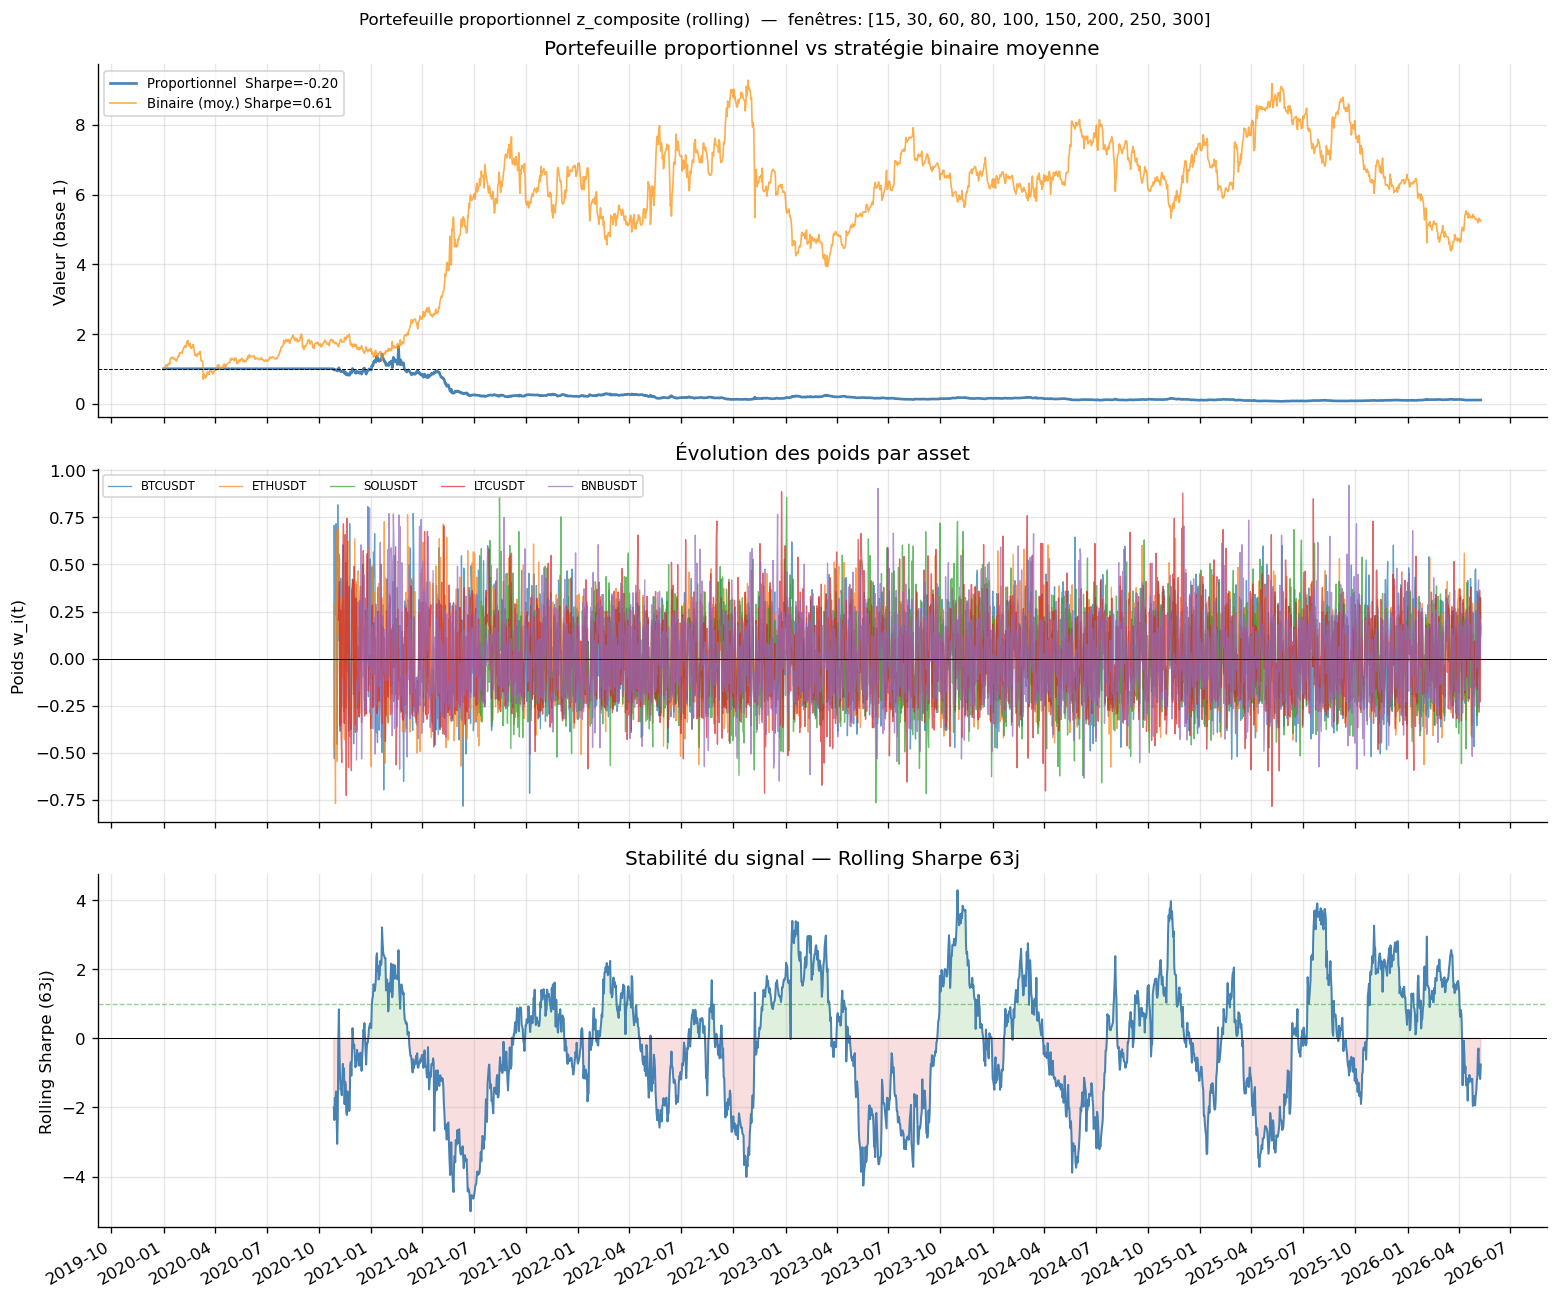

In [18]:
# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# Panel 1 : valeur cumulée proportionnelle vs binaire
ax = axes[0]
ax.plot(port_value.index,      port_value.values,      lw=1.6, color='steelblue',  label=f'Proportionnel  Sharpe={sh_prop:.2f}')
ax.plot(bin_value_mean.index,  bin_value_mean.values,  lw=1.0, color='darkorange', alpha=0.7, label=f'Binaire (moy.) Sharpe={sh_bin:.2f}')
ax.axhline(1, color='k', lw=0.6, ls='--')
ax.set_ylabel('Valeur (base 1)')
ax.set_title('Portefeuille proportionnel vs stratégie binaire moyenne')
ax.legend(fontsize=8)

# Panel 2 : poids par asset dans le temps
ax = axes[1]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
for sym, col in zip(ASSETS, colors):
    w = weights[sym].dropna()
    ax.plot(w.index, w.values, lw=0.8, color=col, alpha=0.7, label=sym)
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('Poids w_i(t)')
ax.set_title('Évolution des poids par asset')
ax.legend(fontsize=7, ncol=5)

# Panel 3 : rolling Sharpe 63j du portefeuille proportionnel
ax = axes[2]
roll_sh = port_ret.rolling(63, min_periods=20).apply(
    lambda x: (x.mean() / x.std()) * np.sqrt(252) if x.std() > 0 else np.nan
)
ax.plot(roll_sh.index, roll_sh.values, lw=1.2, color='steelblue')
ax.fill_between(roll_sh.index, 0, roll_sh.values,
                where=roll_sh.values >= 0, color='tab:green', alpha=0.15)
ax.fill_between(roll_sh.index, 0, roll_sh.values,
                where=roll_sh.values < 0,  color='tab:red',   alpha=0.15)
ax.axhline(0, color='k', lw=0.6)
ax.axhline(1, color='tab:green', lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Rolling Sharpe (63j)')
ax.set_title('Stabilité du signal — Rolling Sharpe 63j')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

fig.suptitle(f'Portefeuille proportionnel z_composite ({METHOD})  —  fenêtres: {WINDOWS}', fontsize=10)
plt.gcf().autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()